In [1]:
import sys, json, os
sys.path.append("..")
import pandas as pd
import matplotlib.pyplot as plt
from src.imbalance import run_strategy

X_train = pd.read_parquet("../data/processed/X_train.parquet")
y_train = pd.read_parquet("../data/processed/y_train.parquet")["_MICHD"]
final = json.load(open("../reports/final_features.json"))["final"]
print(len(final), "features")        # expect 14

14 features


In [2]:
rows = []
for name in ["logreg", "dtree", "xgb", "rf", "knn", "svm"]:
    for strategy in ["none", "class_weight", "undersample"]:
        if name == "knn" and strategy == "class_weight":
            continue                  # KNN has no class-weight option
        row = run_strategy(name, strategy, X_train, y_train, final)
        rows.append(row)
        print(f"{name:7s} {strategy:13s} AUC={row['roc_auc']:.3f}  PR-AUC={row['pr_auc']:.3f}  "
              f"recall={row['recall']:.3f}  spec={row['specificity']:.3f}  ({row['seconds']:.0f}s)")

res = pd.DataFrame(rows)
os.makedirs("../reports", exist_ok=True)
res.to_csv("../reports/imbalance_results.csv", index=False)

logreg  none          AUC=0.824  PR-AUC=0.330  recall=0.077  spec=0.993  (3s)
logreg  class_weight  AUC=0.824  PR-AUC=0.330  recall=0.773  spec=0.722  (1s)
logreg  undersample   AUC=0.824  PR-AUC=0.329  recall=0.547  spec=0.868  (1s)
dtree   none          AUC=0.813  PR-AUC=0.299  recall=0.028  spec=0.997  (1s)
dtree   class_weight  AUC=0.812  PR-AUC=0.299  recall=0.792  spec=0.692  (1s)
dtree   undersample   AUC=0.809  PR-AUC=0.288  recall=0.561  spec=0.841  (0s)
xgb     none          AUC=0.827  PR-AUC=0.334  recall=0.063  spec=0.995  (8s)
xgb     class_weight  AUC=0.827  PR-AUC=0.334  recall=0.794  spec=0.707  (9s)
xgb     undersample   AUC=0.827  PR-AUC=0.332  recall=0.584  spec=0.852  (6s)
rf      none          AUC=0.825  PR-AUC=0.330  recall=0.012  spec=0.999  (12s)
rf      class_weight  AUC=0.825  PR-AUC=0.329  recall=0.776  spec=0.724  (13s)
rf      undersample   AUC=0.825  PR-AUC=0.328  recall=0.542  spec=0.868  (6s)
knn     none          AUC=0.818  PR-AUC=0.316  recall=0.001  s

In [3]:
show = ["roc_auc", "pr_auc", "recall", "specificity", "precision", "f1", "brier"]
res.set_index(["model", "strategy"])[show].round(3)

roc_auc  pr_auc  recall  specificity  precision     f1  \
model  strategy                                                               
logreg none            0.824   0.330   0.077        0.993      0.531  0.135   
       class_weight    0.824   0.330   0.773        0.722      0.223  0.346   
       undersample     0.824   0.329   0.547        0.868      0.300  0.388   
dtree  none            0.813   0.299   0.028        0.997      0.521  0.053   
       class_weight    0.812   0.299   0.792        0.692      0.210  0.332   
       undersample     0.809   0.288   0.561        0.841      0.268  0.362   
xgb    none            0.827   0.334   0.063        0.995      0.558  0.113   
       class_weight    0.827   0.334   0.794        0.707      0.219  0.343   
       undersample     0.827   0.332   0.584        0.852      0.289  0.387   
rf     none            0.825   0.330   0.012        0.999      0.652  0.023   
       class_weight    0.825   0.329   0.776        0.724      0.225  0.349   
       undersample     0.825   0.328   0.542        0.868      0.299  0.385   
knn    none            0.818   0.316   0.001        1.000      0.267  0.001   
       undersample     0.816   0.312   0.459        0.893      0.306  0.367   
svm    none            0.654   0.251   0.017        0.999      0.607  0.034   
       class_weight    0.810   0.273   0.753        0.726      0.221  0.342   
       undersample     0.806   0.323   0.535        0.868      0.295  0.380   

                     brier  
model  strategy             
logreg none          0.073  
       class_weight  0.177  
       undersample   0.116  
dtree  none          0.074  
       class_weight  0.183  
       undersample   0.122  
xgb    none          0.072  
       class_weight  0.176  
       undersample   0.117  
rf     none          0.073  
       class_weight  0.166  
       undersample   0.115  
knn    none          0.074  
       undersample   0.113  
svm    none            NaN  
       class_weight    NaN  
       undersample     NaN

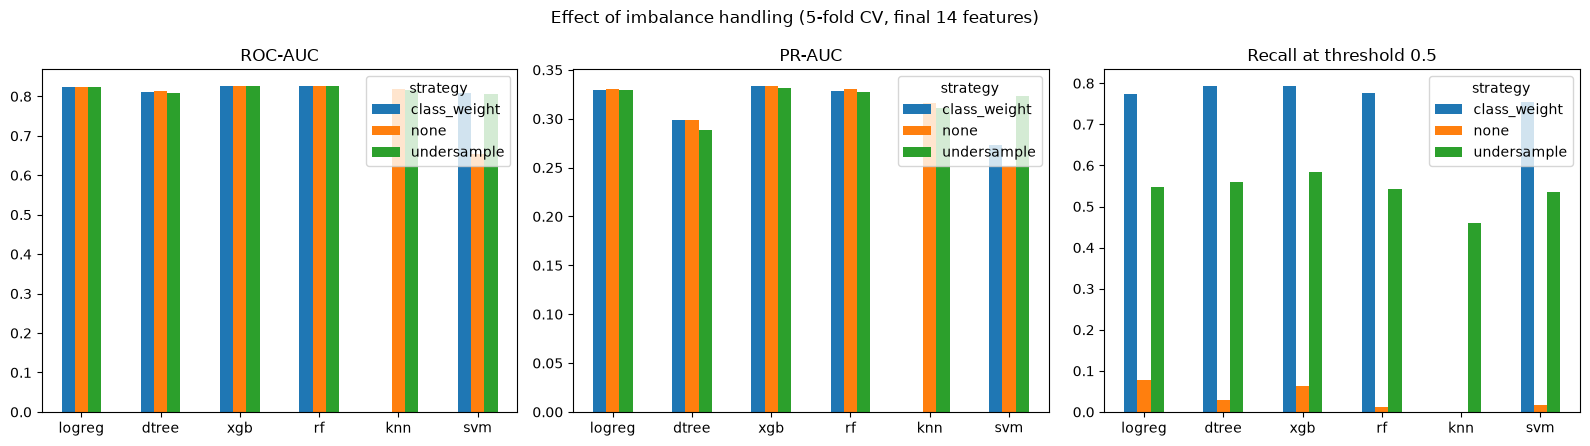

In [4]:
order = ["logreg", "dtree", "xgb", "rf", "knn", "svm"]
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, m, title in zip(axes, ["roc_auc", "pr_auc", "recall"],
                        ["ROC-AUC", "PR-AUC", "Recall at threshold 0.5"]):
    t = res.pivot(index="model", columns="strategy", values=m).loc[order]
    t.plot(kind="bar", ax=ax, rot=0)
    ax.set_title(title)
    ax.set_xlabel("")
plt.suptitle("Effect of imbalance handling (5-fold CV, final 14 features)")
plt.tight_layout()
plt.savefig("../reports/figures/09_imbalance_strategies.png", dpi=300, bbox_inches="tight")
plt.show()

## Imbalance handling findings

Three strategies (none, class weighting, random undersampling to 2:1) were compared for each tuned model inside 5-fold CV (SMOTE was not used: inputs are mostly categorical/ordinal, so interpolated synthetic respondents would be unrealistic).

**Ranking is unaffected.** ROC-AUC was identical across strategies for logistic regression (0.824), XGBoost (0.827) and Random Forest (0.825); PR-AUC changed by ≤ 0.002 under class weighting. Undersampling reduced PR-AUC slightly (0.001–0.011), as it discards data.

**The operating point shifts.** At the default 0.5 threshold, unweighted models detected only 0.1–7.7% of cases at ≥ 99% specificity. Class weighting raised recall to 75–79% (specificity 69–72%, precision about 22%); undersampling gave 46–58% recall (specificity 84–89%, precision 27–31%). The strategies move along the same precision–recall trade-off rather than improving it.

**Probabilities are distorted.** Brier score rose from about 0.073 (unweighted) to 0.166–0.183 (class-weighted) and 0.113–0.122 (undersampled). For reference, predicting the base rate (9.4%) for everyone scores about 0.085, so class-weighted outputs are worse than a constant forecast when read as probabilities.

**SVM.** The untuned-for-imbalance RBF SVM improved from ROC-AUC 0.654 to 0.810 with class weights, confirming imbalance as the cause of its poor baseline performance.

**Decision.** Final models are trained without weighting or resampling to keep probabilities calibrated; sensitivity is set through the decision threshold (next step).